In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('2019-Oct.csv', nrows=1000000)

print(df.shape)
print(df.head())

Matplotlib is building the font cache; this may take a moment.


(1000000, 9)
                event_time event_type  product_id          category_id  \
0  2019-10-01 00:00:00 UTC       view    44600062  2103807459595387724   
1  2019-10-01 00:00:00 UTC       view     3900821  2053013552326770905   
2  2019-10-01 00:00:01 UTC       view    17200506  2053013559792632471   
3  2019-10-01 00:00:01 UTC       view     1307067  2053013558920217191   
4  2019-10-01 00:00:04 UTC       view     1004237  2053013555631882655   

                         category_code     brand    price    user_id  \
0                                  NaN  shiseido    35.79  541312140   
1  appliances.environment.water_heater      aqua    33.20  554748717   
2           furniture.living_room.sofa       NaN   543.10  519107250   
3                   computers.notebook    lenovo   251.74  550050854   
4               electronics.smartphone     apple  1081.98  535871217   

                           user_session  
0  72d76fde-8bb3-4e00-8c23-a032dfed738c  
1  9333dfbd-b87a-4708-985

In [2]:
print(df['event_type'].value_counts())

event_type
view        968513
purchase     16848
cart         14639
Name: count, dtype: int64


In [3]:
views = 968513
carts = 14639
purchases = 16848

cart_rate = (carts / views) * 100
purchase_rate = (purchases / views) * 100
cart_to_purchase = (purchases / carts) * 100

print(f"View → Cart rate: {cart_rate:.2f}%")
print(f"View → Purchase rate: {purchase_rate:.2f}%")
print(f"Cart → Purchase rate: {cart_to_purchase:.2f}%")

View → Cart rate: 1.51%
View → Purchase rate: 1.74%
Cart → Purchase rate: 115.09%


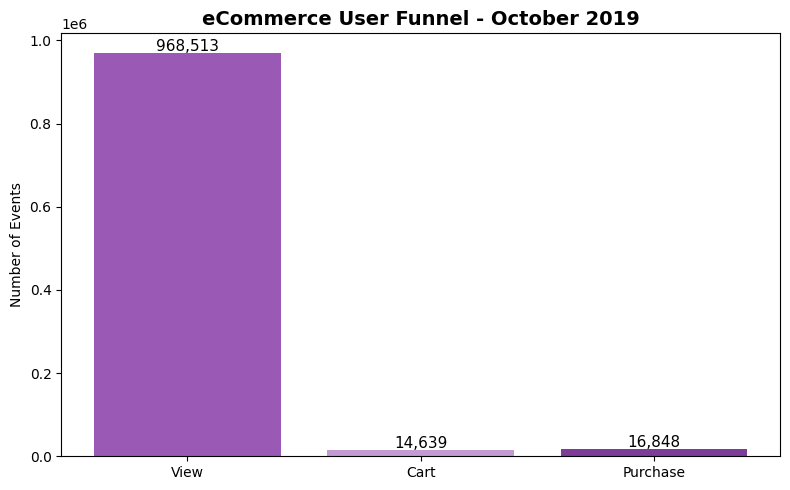

In [4]:
stages = ['View', 'Cart', 'Purchase']
counts = [968513, 14639, 16848]
colors = ['#9b59b6', '#c39bd3', '#7d3c98']

plt.figure(figsize=(8, 5))
bars = plt.bar(stages, counts, color=colors)
plt.title('eCommerce User Funnel - October 2019', fontsize=14, fontweight='bold')
plt.ylabel('Number of Events')

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{count:,}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('funnel_chart.png', dpi=150)
plt.show()

In [5]:
category_funnel = df.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)

category_funnel['view_to_purchase_rate'] = (category_funnel.get('purchase', 0) / category_funnel['view'] * 100).round(2)

category_funnel = category_funnel[category_funnel['view'] > 1000]

top_categories = category_funnel.sort_values('view_to_purchase_rate', ascending=False).head(10)

print(top_categories[['view', 'cart', 'purchase', 'view_to_purchase_rate']])

event_type                             view   cart  purchase  \
category_code                                                  
electronics.audio.headphone           24578   1047       772   
electronics.smartphone               256359  10333      7930   
appliances.environment.water_heater    3930     61       105   
computers.components.hdd               1561     18        39   
appliances.iron                        3778      7        85   
appliances.kitchen.microwave           3548     21        80   
electronics.video.tv                  21153    423       443   
appliances.kitchen.washer             15688    110       300   
appliances.kitchen.kettle              4666     13        86   
appliances.kitchen.meat_grinder        4063      6        71   

event_type                           view_to_purchase_rate  
category_code                                               
electronics.audio.headphone                           3.14  
electronics.smartphone                          

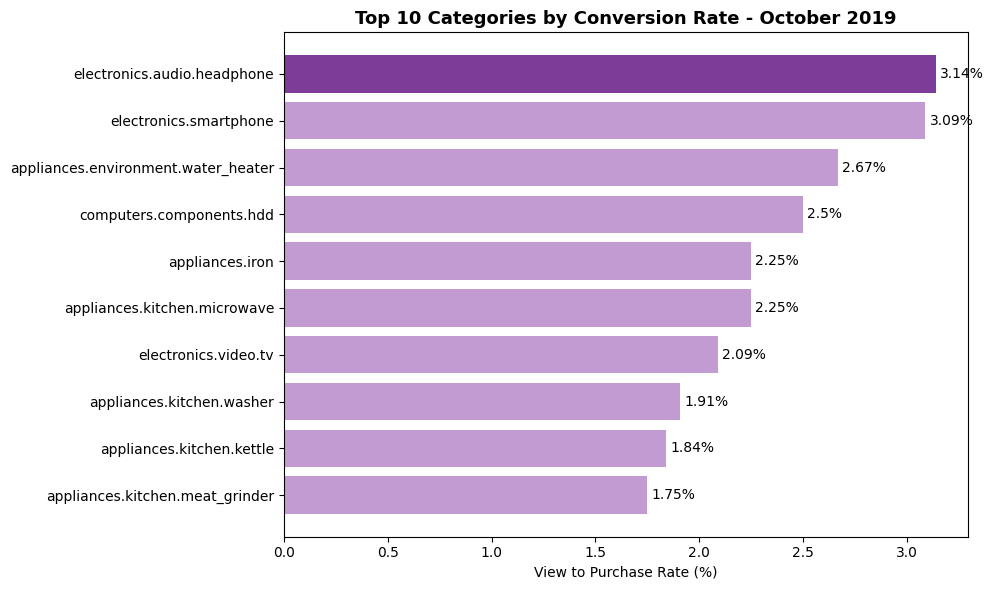

In [6]:
plt.figure(figsize=(10, 6))
colors = ['#7d3c98' if i == 0 else '#c39bd3' for i in range(len(top_categories))]
bars = plt.barh(top_categories.index, top_categories['view_to_purchase_rate'], color=colors)
plt.xlabel('View to Purchase Rate (%)')
plt.title('Top 10 Categories by Conversion Rate - October 2019', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()

for bar, val in zip(bars, top_categories['view_to_purchase_rate']):
    plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('category_conversion.png', dpi=150)
plt.show()

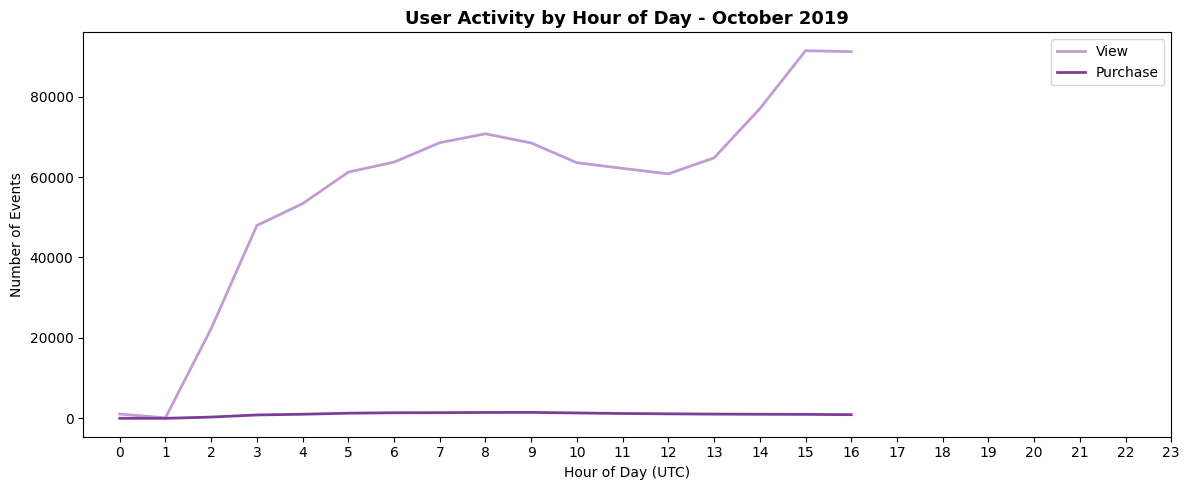

In [7]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['hour'] = df['event_time'].dt.hour

hourly = df.groupby(['hour', 'event_type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
plt.plot(hourly.index, hourly['view'], label='View', color='#c39bd3', linewidth=2)
plt.plot(hourly.index, hourly['purchase'], label='Purchase', color='#7d3c98', linewidth=2)
plt.xlabel('Hour of Day (UTC)')
plt.ylabel('Number of Events')
plt.title('User Activity by Hour of Day - October 2019', fontsize=13, fontweight='bold')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('hourly_activity.png', dpi=150)
plt.show()